In [1]:
import sys
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

sys.path.append(os.path.abspath(os.path.join('..')))
from src.data_loader import load_stock_data
from src.visualizer import plot_daily_candlestick
from src.features import calculate_atr
from src.risk_manager import evaluate_trade_risk
from src.label import create_labels

In [2]:
# Set tanggal dinamis (Contoh: Menarik data dari 6 bulan lalu hingga hari ini)
hari_ini = datetime.now().strftime('%Y-%m-%d')
enam_bulan_lalu = (datetime.now() - timedelta(days=180)).strftime('%Y-%m-%d')

# 1. Panggil data BUMI riil dari Bursa Efek Indonesia (.JK)
# Data ini mencerminkan kondisi pasar riil per Juni 2026
df_bumi = load_stock_data(ticker="BUMI.JK", start_date=enam_bulan_lalu, end_date=hari_ini)
# ------------------------------------------

Mengunduh data terbaru untuk BUMI.JK dari Yahoo Finance...
Berhasil memuat 113 baris data untuk BUMI.JK.
Info Data Cleaning: Menghapus 4 baris data (NaN atau Volume 0).
Berhasil memuat 109 baris data bersih untuk BUMI.JK.


In [3]:
print(df_bumi)

             Open   High    Low  Close       Volume
Date                                               
2025-12-23  402.0  406.0  376.0  380.0   8335353200
2025-12-24  382.0  384.0  360.0  362.0   4795205000
2025-12-29  362.0  376.0  354.0  366.0   5492663300
2025-12-30  370.0  372.0  362.0  366.0   2812869800
2026-01-02  372.0  424.0  370.0  420.0  11771094600
...           ...    ...    ...    ...          ...
2026-06-12  144.0  162.0  143.0  157.0   6630659700
2026-06-15  165.0  191.0  163.0  173.0  13335601700
2026-06-17  175.0  178.0  165.0  168.0   4078182600
2026-06-18  169.0  173.0  163.0  171.0   2760389100
2026-06-19  172.0  177.0  167.0  168.0   2642490700

[109 rows x 5 columns]


Menghasilkan grafik candlestick untuk BUMI...


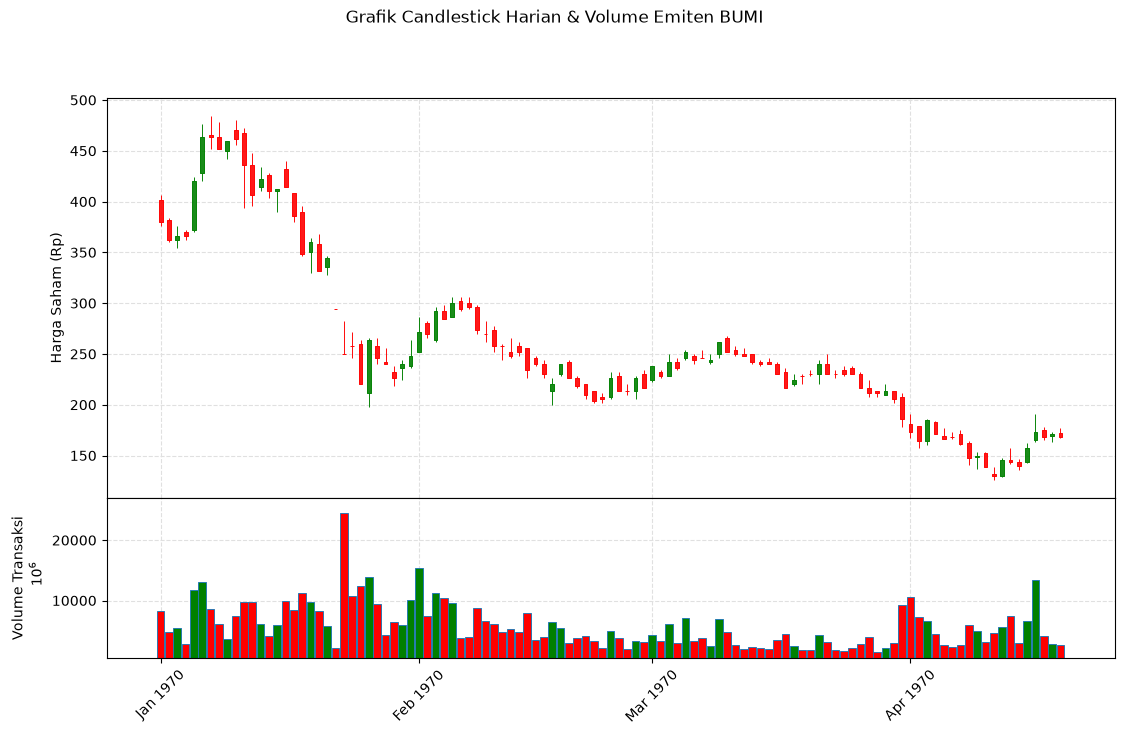

In [4]:
plot_daily_candlestick(df=df_bumi, ticker_name="BUMI")

In [5]:
# df_bumi = calculate_atr(df_bumi)
# latest_data = df_bumi.iloc[-1]
# current_close = float(latest_data['Close'])
# current_atr = float(latest_data['ATR'])

# resisten_terdekat = 186.0  

# trade_analysis = evaluate_trade_risk(
#     entry_price=current_close,
#     atr=current_atr,
#     resistance_level=resisten_terdekat,
#     min_rr_ratio=2.0
# )

# # Cetak Hasil Validasi Hitam-di-Atas-Putih
# print("=== LIVE SYSTEM RISK EVALUATION ===")
# print(f"Harga Masuk Terkini     : Rp{trade_analysis['entry_price']}")
# print(f"Nilai Volatilitas (ATR) : Rp{round(current_atr, 2)}")
# print(f"Garis Aman Cut Loss (SL): Rp{trade_analysis['suggested_stop_loss']} (Terproteksi dari noise)")
# print(f"Target Resisten (TP)    : Rp{trade_analysis['target_profit_resistance']}")
# print(f"Rasio R-to-R Aktual     : {trade_analysis['actual_rr_ratio']}x")
# print("-----------------------------------")

# if trade_analysis['execute_trade']:
#     print("KEPUTUSAN SISTEM: ISI ORDER BELI! Matematika risiko mendukung penuh.")
# else:
#     print("KEPUTUSAN SISTEM: BLOKIR TRANSAKSI! Jarak ke resisten terlalu sempit, batalkan emosi Anda.")

## ADD LABELS

In [6]:
print(df_bumi)

             Open   High    Low  Close       Volume
Date                                               
2025-12-23  402.0  406.0  376.0  380.0   8335353200
2025-12-24  382.0  384.0  360.0  362.0   4795205000
2025-12-29  362.0  376.0  354.0  366.0   5492663300
2025-12-30  370.0  372.0  362.0  366.0   2812869800
2026-01-02  372.0  424.0  370.0  420.0  11771094600
...           ...    ...    ...    ...          ...
2026-06-12  144.0  162.0  143.0  157.0   6630659700
2026-06-15  165.0  191.0  163.0  173.0  13335601700
2026-06-17  175.0  178.0  165.0  168.0   4078182600
2026-06-18  169.0  173.0  163.0  171.0   2760389100
2026-06-19  172.0  177.0  167.0  168.0   2642490700

[109 rows x 5 columns]


In [7]:
HORIZON = 5

df_bumi = load_stock_data(ticker="BUMI.JK", start_date=enam_bulan_lalu, end_date=hari_ini)

labels_list = []
for i in range(len(df_bumi)):
    if i + HORIZON < len(df_bumi):
        entry = df_bumi['Open'].iloc[i]
        
        future_close = df_bumi['Close'].iloc[i : i+HORIZON].values
        future_high = df_bumi['High'].iloc[i : i+HORIZON].values
        future_low = df_bumi['Low'].iloc[i : i+HORIZON].values
        
        label_dict = create_labels(entry, future_close, future_high, future_low)
        label_dict["entry"] = entry
        label_dict["max"] = future_high.max()
        label_dict["min"] = future_low.min()

        labels_list.append(label_dict)
    else:
        labels_list.append({
            "trend_slope": np.nan, 
            "return": np.nan, 
            "risk": np.nan,
            "days_to_max": np.nan,
            "days_to_min": np.nan,
            "entry": np.nan,
            "max": np.nan,
            "min": np.nan
        })

df_labels = pd.DataFrame(labels_list, index=df_bumi.index)
df_bumi = pd.concat([df_bumi, df_labels], axis=1)

df_bumi.head(10)


Mengunduh data terbaru untuk BUMI.JK dari Yahoo Finance...
Berhasil memuat 113 baris data untuk BUMI.JK.
Info Data Cleaning: Menghapus 4 baris data (NaN atau Volume 0).
Berhasil memuat 109 baris data bersih untuk BUMI.JK.


,Open,High,Low,Close,Volume,trend_slope,return,risk,days_to_max,days_to_min,entry,max,min
Date,,,,,,,,,,,,,
2025-12-23,402.0,406.0,376.0,380.0,8335353200,8.4,0.054726,-0.119403,5.0,3.0,402.0,424.0,354.0
2025-12-24,382.0,384.0,360.0,362.0,4795205000,25.8,0.246073,-0.073298,5.0,2.0,382.0,476.0,354.0
2025-12-29,362.0,376.0,354.0,366.0,5492663300,29.4,0.337017,-0.022099,5.0,1.0,362.0,484.0,354.0
2025-12-30,370.0,372.0,362.0,366.0,2812869800,21.6,0.308108,-0.021622,4.0,1.0,370.0,484.0,362.0
2026-01-02,372.0,424.0,370.0,420.0,11771094600,6.8,0.301075,-0.005376,3.0,1.0,372.0,484.0,370.0
2026-01-05,428.0,476.0,420.0,464.0,13048421800,-0.8,0.130841,-0.018692,2.0,1.0,428.0,484.0,420.0
2026-01-06,466.0,484.0,452.0,464.0,8648116700,-4.6,0.038627,-0.154506,1.0,5.0,466.0,484.0,394.0
2026-01-07,464.0,478.0,452.0,452.0,6102514400,-11.6,0.034483,-0.150862,3.0,4.0,464.0,480.0,394.0
2026-01-08,450.0,460.0,442.0,460.0,3629921000,-13.2,0.066667,-0.124444,2.0,3.0,450.0,480.0,394.0


In [8]:
df_bumi.tail(10)

,Open,High,Low,Close,Volume,trend_slope,return,risk,days_to_max,days_to_min,entry,max,min
Date,,,,,,,,,,,,,
2026-06-05,152.0,153.0,139.0,139.0,3062335900,1.6,0.032895,-0.171053,4.0,2.0,152.0,157.0,126.0
2026-06-08,132.0,139.0,126.0,130.0,4621181600,4.8,0.227273,-0.045455,5.0,1.0,132.0,162.0,126.0
2026-06-09,130.0,148.0,129.0,146.0,5625440400,6.7,0.469231,-0.007692,5.0,1.0,130.0,191.0,129.0
2026-06-10,146.0,157.0,142.0,144.0,7438604200,8.1,0.308219,-0.068493,4.0,2.0,146.0,191.0,136.0
2026-06-11,144.0,147.0,136.0,140.0,2994048400,7.3,0.326389,-0.055556,3.0,1.0,144.0,191.0,136.0
2026-06-12,144.0,162.0,143.0,157.0,6630659700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-15,165.0,191.0,163.0,173.0,13335601700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-17,175.0,178.0,165.0,168.0,4078182600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-18,169.0,173.0,163.0,171.0,2760389100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
